INFO:drake:Solved GCS shortest path using Mosek with convex_relaxation=true and preprocessing=true and rounding.
INFO:drake:Found 1 unique paths, discarded 99 duplicate paths.
INFO:drake:Finished 1 rounding solutions with SNOPT.



Solve success: True
Optimal cost: 15.60338329158756



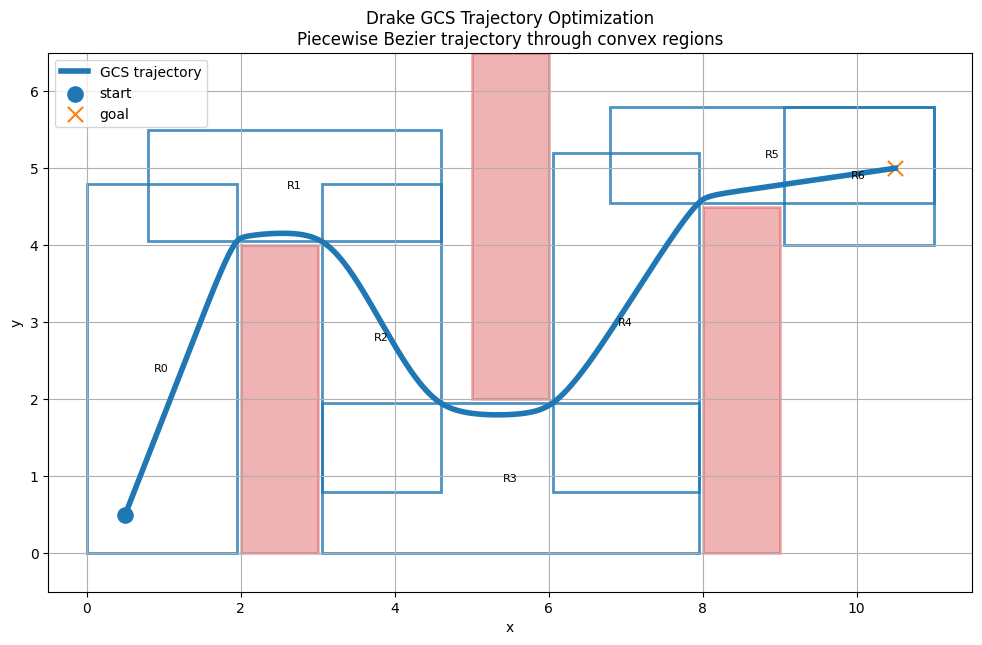

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from pydrake.all import (
    HPolyhedron,
    Point,
    GcsTrajectoryOptimization,
    GraphOfConvexSetsOptions,
)


# ============================================================
# Utilities
# ============================================================

def make_box(box):
    xmin, ymin, xmax, ymax = box
    return HPolyhedron.MakeBox(
        np.array([xmin, ymin]),
        np.array([xmax, ymax]),
    )


def draw_box(ax, box, color="black", alpha=1.0,
             fill=False, linewidth=2, label=None):
    xmin, ymin, xmax, ymax = box

    rect = Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        facecolor=color if fill else "none",
        edgecolor=color,
        linewidth=linewidth,
        alpha=alpha,
    )

    ax.add_patch(rect)

    if label is not None:
        ax.text(
            (xmin + xmax) / 2,
            (ymin + ymax) / 2,
            label,
            ha="center",
            va="center",
            fontsize=8,
        )


def sample_trajectory(traj, N=300):
    ts = np.linspace(
        traj.start_time(),
        traj.end_time(),
        N,
    )

    pts = np.array([
        traj.value(t).ravel()
        for t in ts
    ])

    return pts


# ============================================================
# Main
# ============================================================

def main():

    # ========================================================
    # Obstacles (visualization only)
    # ========================================================

    obstacles = [

        # left block
        (2.0, 0.0, 3.0, 4.0),

        # center block
        (5.0, 2.0, 6.0, 6.5),

        # right block
        (8.0, 0.0, 9.0, 4.5),
    ]

    # ========================================================
    # Convex safe regions
    #
    # IMPORTANT:
    # Neighboring regions intentionally overlap.
    #
    # This creates feasible transitions between regions.
    # ========================================================

    clearance = 0.05

    region_boxes = [

        # ----------------------------------------------------
        # Obstacle-free corridor around the left block.
        # ----------------------------------------------------
        (0.0, 0.0, 2.0 - clearance, 4.8),       # R0: start / left vertical
        (0.8, 4.0 + clearance, 4.6, 5.5),       # R1: over left obstacle

        # ----------------------------------------------------
        # Gap between the left and center blocks, then below
        # the center block.
        # ----------------------------------------------------
        (3.0 + clearance, 0.8, 4.6, 4.8),       # R2: descend in middle gap
        (3.0 + clearance, 0.0, 8.0 - clearance, 2.0 - clearance),  # R3

        # ----------------------------------------------------
        # Gap before the right block, then over the right block
        # to the goal.
        # ----------------------------------------------------
        (6.0 + clearance, 0.8, 8.0 - clearance, 5.2),       # R4
        (6.8, 4.5 + clearance, 11.0, 5.8),                 # R5
        (9.0 + clearance, 4.0, 11.0, 5.8),                 # R6: goal
    ]

    def boxes_have_positive_area_overlap(a, b):
        axmin, aymin, axmax, aymax = a
        bxmin, bymin, bxmax, bymax = b
        return min(axmax, bxmax) > max(axmin, bxmin) and min(aymax, bymax) > max(aymin, bymin)

    for region_index, region_box in enumerate(region_boxes):
        for obstacle_index, obstacle_box in enumerate(obstacles):
            if boxes_have_positive_area_overlap(region_box, obstacle_box):
                raise ValueError(f"Region R{region_index} overlaps obstacle {obstacle_index}")

    # ========================================================
    # Convert to HPolyhedron
    # ========================================================

    regions = [
        make_box(b)
        for b in region_boxes
    ]

    # ========================================================
    # Start / goal
    # ========================================================

    start = np.array([0.5, 0.5])
    goal  = np.array([10.5, 5.0])

    # ========================================================
    # Build GCS trajectory optimization
    # ========================================================

    gcs = GcsTrajectoryOptimization(
        num_positions=2
    )

    # --------------------------------------------------------
    # IMPORTANT:
    #
    # We DO NOT manually specify adjacency here.
    #
    # Drake automatically connects overlapping regions.
    # --------------------------------------------------------

    free_space = gcs.AddRegions(
        regions,
        order=5,      # higher order Bezier
        h_min=0.1,
        h_max=5.0,
        name="free_space",
    )

    source = gcs.AddRegions(
        [Point(start)],
        order=0,
        h_min=0.0,
        h_max=0.0,
        name="source",
    )

    target = gcs.AddRegions(
        [Point(goal)],
        order=0,
        h_min=0.0,
        h_max=0.0,
        name="target",
    )

    # ========================================================
    # Connect source / target
    # ========================================================

    # Source lies inside R0
    gcs.AddEdges(
        source,
        free_space,
        None,
        [(0, 0)],
    )

    # Goal lies inside R6
    gcs.AddEdges(
        free_space,
        target,
        None,
        [(6, 0)],
    )

    # ========================================================
    # Costs
    # ========================================================

    # Short path
    free_space.AddPathLengthCost(1.0)

    # Encourage smoother trajectories
    #
    # This is VERY important.
    #
    # Without this, Bezier segments collapse into
    # nearly straight lines.
    #
   

    # Small time regularization
    free_space.AddTimeCost(0.1)

    # ========================================================
    # Continuity
    # ========================================================

    # C2 continuity for the returned time-parameterized trajectory q(t).
    # Drake requires adding each derivative order from 1 through k.
    free_space.AddContinuityConstraints(1)
    free_space.AddContinuityConstraints(2)

    # ========================================================
    # Velocity bounds
    # ========================================================

    free_space.AddVelocityBounds(
        lb=np.array([-4.0, -4.0]),
        ub=np.array([ 4.0,  4.0]),
    )

    # ========================================================
    # Solve
    # ========================================================

    options = GraphOfConvexSetsOptions()

    trajectory, result = gcs.SolvePath(
        source,
        target,
        options,
    )

    print()
    print("========================================")
    print("Solve success:", result.is_success())
    print("Optimal cost:", result.get_optimal_cost())
    print("========================================")
    print()

    if not result.is_success():
        raise RuntimeError(
            "GCS solve failed.\n"
            "Make sure MOSEK is properly configured."
        )

    # ========================================================
    # Sample trajectory
    # ========================================================

    pts = sample_trajectory(
        trajectory,
        N=500,
    )

    # ========================================================
    # Visualization
    # ========================================================

    fig, ax = plt.subplots(
        figsize=(12, 7)
    )

    # --------------------------------------------------------
    # Draw regions
    # --------------------------------------------------------

    for i, box in enumerate(region_boxes):

        draw_box(
            ax,
            box,
            color="tab:blue",
            alpha=0.8,
            fill=False,
            linewidth=2,
            label=f"R{i}",
        )

    # --------------------------------------------------------
    # Draw obstacles
    # --------------------------------------------------------

    for obs in obstacles:

        draw_box(
            ax,
            obs,
            color="tab:red",
            alpha=0.35,
            fill=True,
            linewidth=2,
        )

    # --------------------------------------------------------
    # Draw trajectory
    # --------------------------------------------------------

    ax.plot(
        pts[:, 0],
        pts[:, 1],
        linewidth=4,
        label="GCS trajectory",
    )

    # --------------------------------------------------------
    # Start / goal
    # --------------------------------------------------------

    ax.scatter(
        start[0],
        start[1],
        s=120,
        marker="o",
        label="start",
    )

    ax.scatter(
        goal[0],
        goal[1],
        s=120,
        marker="x",
        label="goal",
    )

    # --------------------------------------------------------
    # Plot formatting
    # --------------------------------------------------------

    ax.set_aspect("equal")

    ax.set_xlim(-0.5, 11.5)
    ax.set_ylim(-0.5, 6.5)

    ax.set_xlabel("x")
    ax.set_ylabel("y")

    ax.set_title(
        "Drake GCS Trajectory Optimization\n"
        "Piecewise Bezier trajectory through convex regions"
    )

    ax.grid(True)
    ax.legend()

    plt.show()


if __name__ == "__main__":
    main()